<h1 style="margin-bottom: 7px;"> Classical Image representation </h1>
In the classical representation, a black and white image is a <b>matrix of integers</b>, where every position represent a pixel, and the integer represent the color intensity.

In [1]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

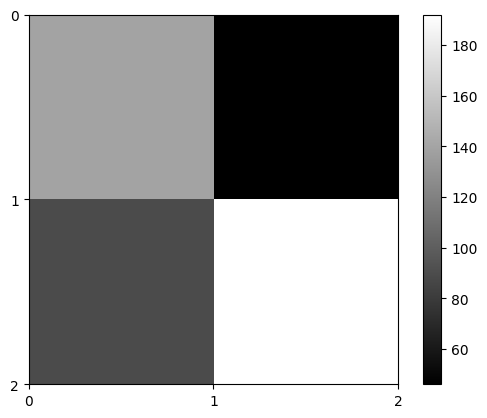

In [2]:
img = Image.open("test6.bmp").convert('L')
plt.imshow(img, cmap="gray", extent=[0, 2, 2, 0])
plt.xticks(range(0, 3))
plt.yticks(range(0, 3))
plt.colorbar()
plt.show()

The numpy array behind shows the image-encoding for classical computation

In [3]:
print(np.array(img))

[[140  46]
 [ 89 192]]


<br>
<br>
<br>

<h1 style="margin-bottom: 7px;">Novel Enhanced Quantum Representation (NEQR)</h1>
The idea behind this approach for a quantistic image representation is to optimise memory by encoding all the the pixel into one single quantum register, taking advantage of the superposition property.

$$
|I\rangle = \frac{1}{2^n} \sum_{Y=0}^{2^n-1} \sum_{X=0}^{2^n-1} | f(Y, X) \rangle \otimes | YX \rangle
$$


**Where:**    
- $| f(Y, X) \rangle$ represents the grayscale intensity, also written as $|C^{i}_{YX}\rangle$ 
- $| YX \rangle$ represent the pixel position

The Quantum Circuit creates a **superposition of the positional and color registers** for a $2^n\times  2^n$ image.

<h2 style="margin-bottom: 3px;">NEQR: Code Implementation</h2>
<h2 style="margin-bottom: 3px;">Image preparation</h2>
By first, we create an array of bits by normalizing and converting the oginal matrix.

In [4]:
bit_matrix_img = np.vectorize(lambda x: format(x, "02b"))(np.array(img) // 64)

In [5]:
print(bit_matrix_img)

[['10' '00']
 ['01' '11']]


To calculate the Qubits needed for the circuit the general formula is $q + 2n$  to represent a $2^n\times  2^n$ image with gray range $2^{q}$.  
In this case, we use a **2-bit color representation**, for 4 different levels of gray intensity. 

In [6]:
img_width = len(bit_matrix_img) #since the image is square, width and height are the same
n_positions = int(np.ceil(np.log2(img_width))*2)
q = int(np.log2(4))

n_qubits = n_positions + q

In [7]:
print(n_qubits, n_positions, q, sep=', ')

4, 2, 2


<h2 style="margin-bottom: 8px;">First step</h2>
To initialise the <b>Quantum Circuit</b>, all the Qubits must be set to $|0\rangle$:  
<div style="margin-bottom: 0.4cm;"></div>
$$|\psi\rangle_{0} = |0\rangle^{\otimes2n+q}$$

In [8]:
from qiskit import QuantumCircuit

In [9]:
qc = QuantumCircuit(n_qubits)
initial_state = np.zeros(2**n_qubits)
initial_state[0] = 1

qc.initialize(initial_state, range(n_qubits));

After the first step, the Quantum State is as follows:
$$
|\psi\rangle_0 = 
\begin{bmatrix}
1 \\
0 \\
\vdots \\
0
\end{bmatrix}
$$

In this specific case, the image is $2px \times 2px$, so the state has $2 + 2\log_2 2 = 4$ Qubits.

<h2 style="margin-bottom: 8px;">Second step</h2>
The position register is brought into a superposition state while the color registers remain unaltered.
Formally, $U_1$ is applied, such that:
<div style="margin-bottom: 0.4cm;"></div>
$$U_1 = I^{\otimes q} \otimes H^{\otimes 2n}$$

The Quantum state after this operation can be written as:
<div style="margin-bottom: 0.4cm;"></div>
$$|\psi\rangle_{1} = \frac{1}{2^n} \sum_{Y=0}^{2^n -1} \sum_{X=0}^{2^n -1} |0\rangle^{\otimes q} |XY\rangle$$

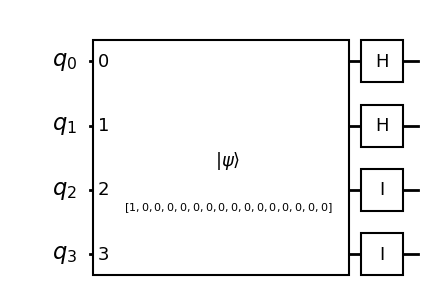

In [10]:
for i in range(n_positions):
    qc.h(i)
    
for i in range(n_positions, n_qubits):
    qc.id(i)

qc.draw('mpl', style='bw')

In a probabilistic interpretation, the state can collapse with equal probability onto one of the position Qubits.

<h2 style="margin-bottom: 8px;">Third step</h2>
The final step consists in setting the greyscale value for each pixel. Formally, $U_{YX}$ is applied, such that:
<div style="margin-bottom: 0.4cm;"></div>
$$
U_{YX}= \Big(I \otimes \sum^{2^n -1}_{j=0} \sum^{2^n -1}_{i=0, ji \neq YX} |ji\rangle \langle ji| \Big) + \Omega_{YX} \otimes |YX\rangle \langle YX|
$$
<div style="margin-bottom: 0.3cm;"></div>
<h4 style="margin-bottom: 8px;">Detailed Analysis of the Operator $U_{YX}$</h4>
The operator $U_{YX}$ can be decomposed into two different sub-operations to better understand its role. The <b>first sub-operation</b>, $U'_{YX}$, is written as follows:
<div style="margin-bottom: 0.4cm;"></div>
$$U'_{YX} = \Big(I \otimes \sum^{2^n -1}_{j=0} \sum^{2^n -1}_{i=0, \hspace{0.2em} ji \neq YX} |ji\rangle \langle ji| \Big)$$
<div style="margin-bottom: 0.4cm;"></div>
This part handles all the pixels exepts for $YX$, leaving their quantum states unaffected. Inside the summation, we have a <b>projection operator</b> $|ji\rangle \langle ji|$, which, when applied to $|ji\rangle$, results in  $|ji\rangle$. If applied to any other state, it gives $0$. Formally:
<div style="margin-bottom: 0.4cm;"></div>
$$
|ji\rangle \langle ji||ab\rangle = 
\begin{cases}
|ji\rangle & \scriptsize{if} \hspace{0.5em} ab = ji \\
0 & \scriptsize{if} \hspace{0.5em} ab \neq ji
\end{cases}
$$
<div style="margin-bottom: 0.4cm;"></div>

The <b>second sub-operation</b>, $U''_{YX}$, is written as follows:
<div style="margin-bottom: 0.3cm;"></div>
$$
U''_{YX} = \Omega_{YX} \otimes |YX\rangle \langle YX|
$$
<div style="margin-bottom: 0.3cm;"></div>
The projection operator ensures that the greyscale transformation is applied only to the specific pixel $(Y,X)$. The operator $\Omega_{YX}$ is the quantum operation designed for setting the greyscale levels for pixel $(Y,X)$:
<div style="margin-bottom: 0.3cm;"></div>
$$
\Omega_{YX} = \bigotimes^{q-1}_{i=0}\Omega^i_{YX}
$$
<div style="margin-bottom: 0.3cm;"></div>
With $\Omega^i_{YX}$ quantum oracles:
<div style="margin-bottom: 0.3cm;"></div>
$$
\Omega^i_{YX}:|0\rangle \to \Big\vert \hspace{0.2em} 0 \oplus C^i_{YX}\Big\rangle
$$

When the operator is applied to the initial quantum state, the result is:
<div style="margin-bottom: 0.4cm;"></div>
$$
U_{YX}(|\psi\rangle_{1}) = \frac{1}{2^n} \Big(\sum_{j=0}^{2^n -1} \sum_{i=0, \hspace{0.2em}ji \neq YX}^{2^n -1} |0\rangle^{\otimes q} |ji\rangle + |f(Y,X)\rangle |YX\rangle \Big)
$$
<div style="margin-bottom: 0.4cm;"></div>
Since the operator $U_{YX}$ corresponds to a specific position, to determine the quantum state $|\psi\rangle_{2}$, $U_2$ is introduced, such that:
<div style="margin-bottom: 0.4cm;"></div>
$$
U_2 = \prod^{2^n -1}_{Y=0} \prod^{2^n -1}_{X=0} U_{YX}
$$
<div style="margin-bottom: 0.4cm;"></div>
Thus, the final Quantum State is:
<div style="margin-bottom: 0.4cm;"></div>
$$
|\psi\rangle_2 = U_{2}(|\psi\rangle_{1}) = \frac{1}{2^n} \Big(\sum_{Y=0}^{2^n -1} \sum_{X=0}^{2^n -1} |f(Y,X)\rangle |YX\rangle \Big)
$$

In [11]:
h, w = img_width, img_width

for Y in range(h):
    for X in range(w):
        qc.barrier()
        bin_Y = bin(Y)[2:].zfill(int(np.log2(h)))
        bin_X = bin(X)[2:].zfill(int(np.log2(w)))
        pos_bin =  bin_Y + bin_X
        
        for i, bit in enumerate(pos_bin):
           if bit == '1':
                qc.x(i)
        
        f_YX = bit_matrix_img[Y,X]  
        control_qubits = [i for i, bit in enumerate(pos_bin) if bit == '1']
        for i, bit in enumerate(f_YX[::-1]):
           if bit == '1' and control_qubits != []:
                qc.mcx(control_qubits, n_qubits-i-1)

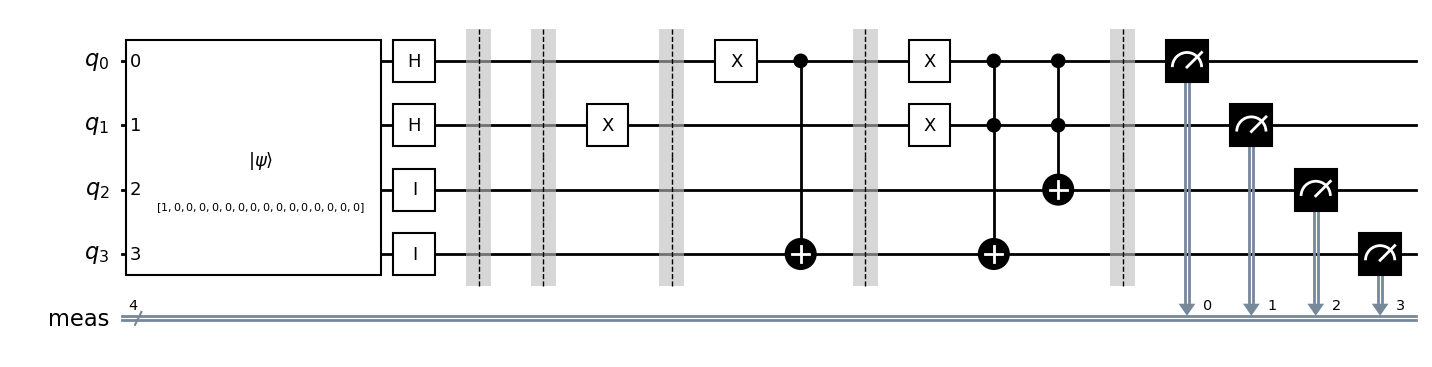

In [12]:
qc.measure_all()
qc.draw('mpl', style='bw', fold=35)

<h3>The final encoding</h3>
<div style="margin-bottom: 0.4cm;"></div>
$$
|\psi\rangle_2 = \frac{1}{2^2} \Big(|00\rangle|10\rangle + |01\rangle|00\rangle + |10\rangle|01\rangle + |11\rangle|11\rangle\Big)
$$
<div style="margin-bottom: 0.4cm;"></div>
<h3>Getting the counts</h3>

In [13]:
from qiskit_aer import Aer
from qiskit import transpile

In [14]:
simulator = Aer.get_backend('qasm_simulator')
transpiled_circuit = transpile(qc, simulator)
job = simulator.run(transpiled_circuit, shots=10000)
res = job.result()
counts = res.get_counts()

In [15]:
print(counts, '\n\n', bit_matrix_img)
#c0 c1 are the grey code
#c2 c3 are Y X

{'1010': 2475, '1000': 2448, '1111': 2588, '0001': 2489} 

 [['10' '00']
 ['01' '11']]


<h2> Are there any advantages?</h2>
In this case the image has taken $2 \times 2 \times 2 = 8$<i>bits</i>, compared to the $4$<i>qubits</i> we used.<br> 
We now compare the formulas: 
$$ \text{Bits} =w \times h \times q$$
$$ \hspace{17em}\text{Qubits} =q + 2n \hspace{2em}\text{with} \hspace{2em} n = \lceil\log_2(w)\rceil = \lceil\log_2(h)\rceil$$ 
Making the assumptions that we only operate with square images and with <i>q</i> fixed, we can plot the memory usage.

In [16]:
q = 2
wh_values = np.arange(2, 11, 2)
n_qubits = q + 2 * np.ceil(np.log2(wh_values)).astype(int)
n_bits = q * wh_values * wh_values

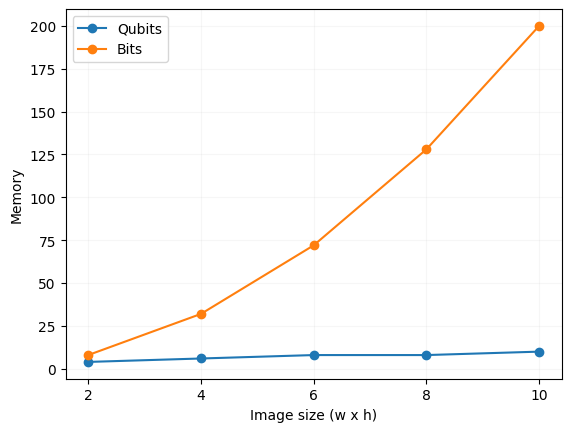

In [17]:
plt.plot(wh_values, n_qubits, marker='o')
plt.plot(wh_values, n_bits, marker='o')
plt.grid(alpha=0.1)
plt.xlabel("Image size (w x h)")
plt.ylabel("Memory")
plt.xticks(wh_values)
plt.legend(['Qubits', 'Bits'])
plt.show()

It is already noticeble how the number of qubits grows linearly, against the exponential growht of the bits.<br>
With $q=2$, $h = w = 8$ 
$$ \text{Bits} =8 \times 8 \times 2 = 128$$
$$ \text{Qubits} =2 + 2\log_28 = 8$$
<h3>Let's try with real numbers!</h3>
For a black and white high definition square image:<br> $q=8$, $h = w = 2048$ 

In [18]:
q2 = 8
wh2_values = np.arange(2, 2049, 2)
n2_qubits = q2 + 2 * np.ceil(np.log2(wh2_values)).astype(int)
n2_bits = q2 * wh2_values * wh2_values

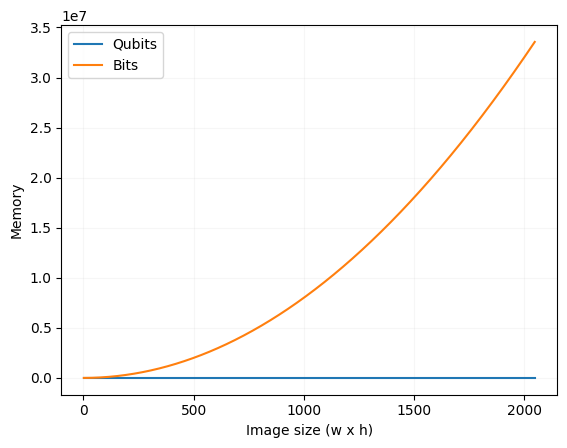

In [19]:
plt.plot(wh2_values, n2_qubits)
plt.plot(wh2_values, n2_bits)
plt.grid(alpha=0.1)
plt.xlabel("Image size (w x h)")
plt.ylabel("Memory")
plt.legend(['Qubits', 'Bits'])
plt.show()

$$ \text{Bits} =2048 \times 2048 \times 8 = 33.226.752$$
$$ \text{Qubits} =8 + 2\log_2(2048) = 30$$

<h2>Conclusion</h2>
Beyond the advantage in memory usage without any compression algorithm, the Novel Enhanced Quantum Representation can be convenient in other aspects. However, like any technique, it may also have its drawbacks, which should be carefully considered depending on the specific application.

<h4>Filtering and Transforming</h4>
In Classical Computation, a standard transformation can be performed with a time complexity of $O(N)$, by iterating along the full matrix. However, by taking advantage of superposition, we can potentially perform the same operation with a time complexity of $O(logN)$, achieving an exponential improvement.<br>
But the real advantages emerge when we apply a filter. <br>
In classical computation, applying a filter by <b>convolution</b> takes $O(KN)$, with K being the size of the filter. It is evident that with big filters, the complexity approaches $O(N^2)$. Thanks to the <b>Convolution Theorem</b>, we can reduce this complexity to $O(NlogN)$, using the <b>Fast Fourier Trasform</b>.<br>
With Quantum Computation, we can take it a step further. The performance of a <b>Quantum Fourier Transform</b>, without considering the measurement phase, takes $O(log^2N)$, thanks to the quantum parallelism.

<h4>Pixel Access</h4>
While every access in the Classical Computation takes $O(1)$ without affecting the other pixels, in the NEQR, informations are stored differently. Each individual access collpases the entire quantum state. Therefore, it is necessary to measure the system to get all the position-color pairs.

<br>
In conclusion, while the theoretical advantages of NEQR and quantum computation are fascinating, practical considerations must be addressed before they can be widely applied. With advances in quantum hardware and error correction, these methods may become more viable for specific applications, but for now, classical techniques remain highly effective for many real-world scenarios.